In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [61]:
loan=pd.read_csv("loan-train.csv")

In [62]:
loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1614 entries, 0 to 1613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            1614 non-null   object 
 1   Gender             1601 non-null   object 
 2   Married            1611 non-null   object 
 3   Dependents         1599 non-null   object 
 4   Education          1614 non-null   object 
 5   Self_Employed      1582 non-null   object 
 6   ApplicantIncome    1614 non-null   int64  
 7   CoapplicantIncome  1614 non-null   float64
 8   LoanAmount         1592 non-null   float64
 9   Loan_Amount_Term   1600 non-null   float64
 10  Credit_History     1564 non-null   float64
 11  Property_Area      1614 non-null   object 
 12  Loan_Status        1614 non-null   object 
dtypes: float64(4), int64(1), object(8)
memory usage: 164.1+ KB


In [63]:
loan.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [64]:
loan.Gender.unique()

array(['Male', 'Female', nan], dtype=object)

In [65]:
loan[loan.Gender.isna()]

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
23,LP001050,NaN,Yes,2,Not Graduate,No,3365,1917.0,112.0,360.0,0.0,Rural,N
126,LP001448,NaN,Yes,3+,Graduate,No,23803,0.0,370.0,360.0,1.0,Rural,Y
171,LP001585,NaN,Yes,3+,Graduate,No,51763,0.0,700.0,300.0,1.0,Urban,Y
188,LP001644,NaN,Yes,0,Graduate,Yes,674,5296.0,168.0,360.0,1.0,Rural,Y
314,LP002024,NaN,Yes,0,Graduate,No,2473,1843.0,159.0,360.0,1.0,Rural,N
334,LP002103,NaN,Yes,1,Graduate,Yes,9833,1833.0,182.0,180.0,1.0,Urban,Y
460,LP002478,NaN,Yes,0,Graduate,Yes,2083,4083.0,160.0,360.0,NaN,Semiurban,Y
467,LP002501,NaN,Yes,0,Graduate,No,16692,0.0,110.0,360.0,1.0,Semiurban,Y
477,LP002530,NaN,Yes,2,Graduate,No,2873,1872.0,132.0,360.0,0.0,Semiurban,N
507,LP002625,NaN,No,0,Graduate,No,3583,0.0,96.0,360.0,1.0,Urban,N


In [66]:
loan.Gender.value_counts()

Gender
Male      980
Female    621
Name: count, dtype: int64

In [67]:
loan.Gender.mode()[0]

'Male'

In [68]:
loan.Gender=loan.Gender.fillna(loan.Gender.mode()[0])

In [69]:
loan[loan.Gender.isna()]

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status


In [70]:
loan.Gender.unique()

array(['Male', 'Female'], dtype=object)

In [71]:
loan[loan.Married.isna()]

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
104,LP001357,Male,NaN,NaN,Graduate,No,3816,754.0,160.0,360.0,1.0,Urban,Y
228,LP001760,Male,NaN,NaN,Graduate,No,4758,0.0,158.0,480.0,1.0,Semiurban,Y
435,LP002393,Female,NaN,NaN,Graduate,No,10047,0.0,NaN,240.0,1.0,Semiurban,Y


In [72]:
loan.Married.mode()[0]

'Yes'

In [73]:
loan.Married=loan.Married.fillna(loan.Married.mode()[0])

In [74]:
loan.Married.unique()

array(['No', 'Yes'], dtype=object)

In [75]:
loan[loan.Dependents.isna()]

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
102,LP001350,Male,Yes,NaN,Graduate,No,13650,0.0,NaN,360.0,1.0,Urban,Y
104,LP001357,Male,Yes,NaN,Graduate,No,3816,754.0,160.0,360.0,1.0,Urban,Y
120,LP001426,Male,Yes,NaN,Graduate,No,5667,2667.0,180.0,360.0,1.0,Rural,Y
226,LP001754,Male,Yes,NaN,Not Graduate,Yes,4735,0.0,138.0,360.0,1.0,Urban,N
228,LP001760,Male,Yes,NaN,Graduate,No,4758,0.0,158.0,480.0,1.0,Semiurban,Y
293,LP001945,Female,No,NaN,Graduate,No,5417,0.0,143.0,480.0,0.0,Urban,N
301,LP001972,Male,Yes,NaN,Not Graduate,No,2875,1750.0,105.0,360.0,1.0,Semiurban,Y
332,LP002100,Male,No,NaN,Graduate,No,2833,0.0,71.0,360.0,1.0,Urban,Y
335,LP002106,Male,Yes,NaN,Graduate,Yes,5503,4490.0,70.0,NaN,1.0,Semiurban,Y
346,LP002130,Male,Yes,NaN,Not Graduate,No,3523,3230.0,152.0,360.0,0.0,Rural,N


In [76]:
loan.Dependents.fillna('0',inplace=True)

C:\Users\UT DELL\AppData\Local\Temp\ipykernel_5232\1664368323.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  loan.Dependents.fillna('0',inplace=True)


In [77]:
loan.Dependents.unique()

array(['0', '1', '2', '3+'], dtype=object)

In [78]:
loan.Dependents = loan.Dependents.replace('3+', '3')

In [79]:
loan.Dependents = loan.Dependents.astype(int)

In [80]:
loan.Dependents.unique()

array([0, 1, 2, 3])

In [82]:
loan.Dependents.dtype

dtype('int64')

In [84]:
loan[loan.Education.isna()]

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status


In [85]:
loan.Education.unique()

array(['Graduate', 'Not Graduate'], dtype=object)

In [87]:
loan[loan.Self_Employed.isna()]

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
11,LP001027,Male,Yes,2,Graduate,NaN,2500,1840.0,109.0,360.0,1.0,Urban,Y
19,LP001041,Male,Yes,0,Graduate,NaN,2600,3500.0,115.0,NaN,1.0,Urban,Y
24,LP001052,Male,Yes,1,Graduate,NaN,3717,2925.0,151.0,360.0,NaN,Semiurban,N
29,LP001087,Female,No,2,Graduate,NaN,3750,2083.0,120.0,360.0,1.0,Semiurban,Y
30,LP001091,Male,Yes,1,Graduate,NaN,4166,3369.0,201.0,360.0,NaN,Urban,N
95,LP001326,Male,No,0,Graduate,NaN,6782,0.0,NaN,360.0,NaN,Urban,N
107,LP001370,Male,No,0,Not Graduate,NaN,7333,0.0,120.0,360.0,1.0,Rural,N
111,LP001387,Female,Yes,0,Graduate,NaN,2929,2333.0,139.0,360.0,1.0,Semiurban,Y
114,LP001398,Male,No,0,Graduate,NaN,5050,0.0,118.0,360.0,1.0,Semiurban,Y
158,LP001546,Male,No,0,Graduate,NaN,2980,2083.0,120.0,360.0,1.0,Rural,Y


In [89]:
loan.Self_Employed.mode()[0]

'No'

In [91]:
loan.Self_Employed=loan.Self_Employed.fillna(loan.Self_Employed.mode()[0])

In [92]:
loan.Self_Employed.unique()

array(['No', 'Yes'], dtype=object)

In [94]:
loan[loan.ApplicantIncome.isna()]

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status


In [95]:
loan.ApplicantIncome.unique()

array([ 5849,  4583,  3000, ..., 19409,  8997, 19858], shape=(1455,))

In [96]:
loan.ApplicantIncome.value_counts()

ApplicantIncome
2500     10
4583      6
6000      6
2600      6
3750      5
         ..
17914     1
11090     1
12972     1
8577      1
19858     1
Name: count, Length: 1455, dtype: int64

In [98]:
loan.ApplicantIncome.dtype

dtype('int64')

In [100]:
loan.CoapplicantIncome.isna().sum()

np.int64(0)

In [101]:
loan.CoapplicantIncome.unique()

array([   0., 1508., 2358., ...,  768., 1354., 6305.], shape=(1206,))

In [102]:
loan.CoapplicantIncome.dtype

dtype('float64')

In [104]:
loan.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [107]:
loan.LoanAmount.isna().sum()

np.int64(22)

<Axes: ylabel='LoanAmount'>

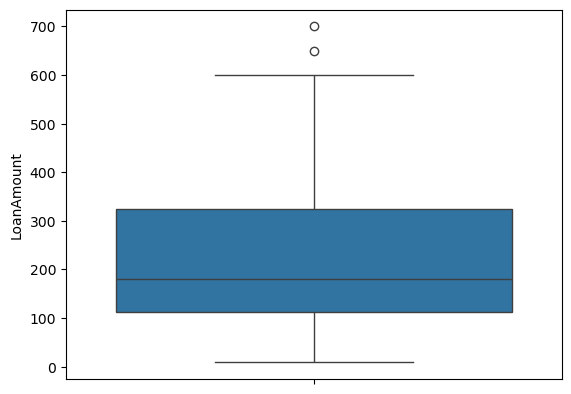

In [111]:
sns.boxplot(loan.LoanAmount)

In [112]:
loan.LoanAmount.mean()

np.float64(218.8467336683417)

In [114]:
loan.LoanAmount=loan.LoanAmount.fillna(loan.LoanAmount.mean())

In [115]:
loan.LoanAmount.unique()

array([218.84673367, 128.        ,  66.        , 120.        ,
       141.        , 267.        ,  95.        , 158.        ,
       168.        , 349.        ,  70.        , 109.        ,
       200.        , 114.        ,  17.        , 125.        ,
       100.        ,  76.        , 133.        , 115.        ,
       104.        , 315.        , 116.        , 112.        ,
       151.        , 191.        , 122.        , 110.        ,
        35.        , 201.        ,  74.        , 106.        ,
       320.        , 144.        , 184.        ,  80.        ,
        47.        ,  75.        , 134.        ,  96.        ,
        88.        ,  44.        , 286.        ,  97.        ,
       135.        , 180.        ,  99.        , 165.        ,
       258.        , 126.        , 312.        , 136.        ,
       172.        ,  81.        , 187.        , 113.        ,
       176.        , 130.        , 111.        , 167.        ,
       265.        ,  50.        , 210.        , 175.  

In [116]:
loan.LoanAmount.dtype

dtype('float64')

In [117]:
loan.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [118]:
loan.Loan_Amount_Term.isna().sum()

np.int64(14)

<Axes: ylabel='Loan_Amount_Term'>

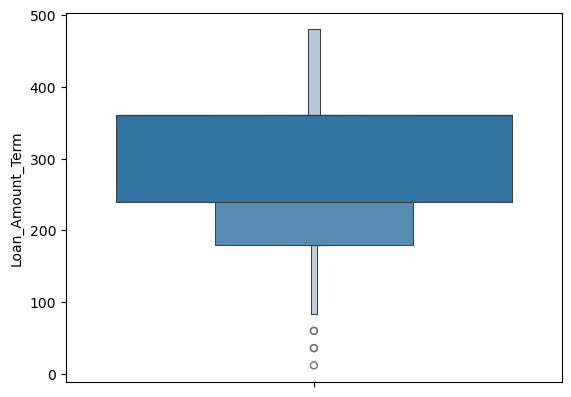

In [119]:
sns.boxenplot(loan.Loan_Amount_Term)

In [120]:
loan.Loan_Amount_Term.mean()

np.float64(290.475)

In [122]:
loan.Loan_Amount_Term=loan.Loan_Amount_Term.fillna(loan.Loan_Amount_Term.mean())

In [123]:
loan.Credit_History.unique()

array([ 1.,  0., nan])

In [127]:
loan.Credit_History=loan.Credit_History.fillna(loan.Credit_History.mode()[0])

In [128]:
loan.Property_Area.isna().sum()

np.int64(0)

In [129]:
loan.Property_Area.unique()

array(['Urban', 'Rural', 'Semiurban'], dtype=object)

In [130]:
loan.Loan_Status.isna().sum()

np.int64(0)

In [131]:
loan.Loan_Status.unique()

array(['Y', 'N'], dtype=object)

In [132]:
loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1614 entries, 0 to 1613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            1614 non-null   object 
 1   Gender             1614 non-null   object 
 2   Married            1614 non-null   object 
 3   Dependents         1614 non-null   int64  
 4   Education          1614 non-null   object 
 5   Self_Employed      1614 non-null   object 
 6   ApplicantIncome    1614 non-null   int64  
 7   CoapplicantIncome  1614 non-null   float64
 8   LoanAmount         1614 non-null   float64
 9   Loan_Amount_Term   1614 non-null   float64
 10  Credit_History     1614 non-null   float64
 11  Property_Area      1614 non-null   object 
 12  Loan_Status        1614 non-null   object 
dtypes: float64(4), int64(2), object(7)
memory usage: 164.1+ KB


<Axes: ylabel='ApplicantIncome'>

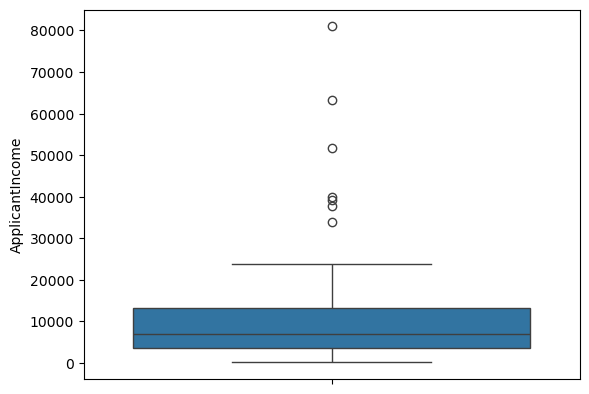

In [133]:
sns.boxplot(loan.ApplicantIncome)

In [138]:
numeric_cols = loan.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    Q1 = loan[col].quantile(0.25)
    Q3 = loan[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = loan[(loan[col] < lower_bound) | (loan[col] > upper_bound)]
    print(f"Column '{col}' has {len(outliers)} outliers.")

Column 'Dependents' has 0 outliers.
Column 'ApplicantIncome' has 7 outliers.
Column 'CoapplicantIncome' has 4 outliers.
Column 'LoanAmount' has 2 outliers.
Column 'Loan_Amount_Term' has 3 outliers.
Column 'Credit_History' has 0 outliers.


In [140]:

print(f"Dataset shape BEFORE removing outliers: {loan.shape}")


columns_with_outliers = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']


for col in columns_with_outliers:
    Q1 = loan[col].quantile(0.25)
    Q3 = loan[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
  
    loan =loan[(loan[col] >= lower_bound) & (loan[col] <= upper_bound)]

print(f"Dataset shape AFTER removing outliers: {loan.shape}")

Dataset shape BEFORE removing outliers: (1614, 13)
Dataset shape AFTER removing outliers: (1599, 13)


In [141]:
loan.describe()

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,1.191370,8587.706692,3616.052483,218.110462,290.745872,0.644778
std,1.146208,5544.922380,3008.452343,131.545298,80.718603,0.478730
min,0.000000,150.000000,0.000000,9.000000,60.000000,0.000000
25%,0.000000,3691.500000,1000.500000,112.000000,240.000000,0.000000
50%,1.000000,7032.000000,2961.000000,182.000000,360.000000,1.000000
75%,2.000000,13180.000000,5891.000000,322.000000,360.000000,1.000000
max,3.000000,23803.000000,11300.000000,600.000000,480.000000,1.000000


In [144]:
# These three columns(ApplicantIncome, CoapplicantIncome, and LoanAmount) are the continuous numeric variables in loan_train dataset.So we draw
# hist plot for these columns.

Text(0.5, 1.0, 'Distribution of Applicant Income')

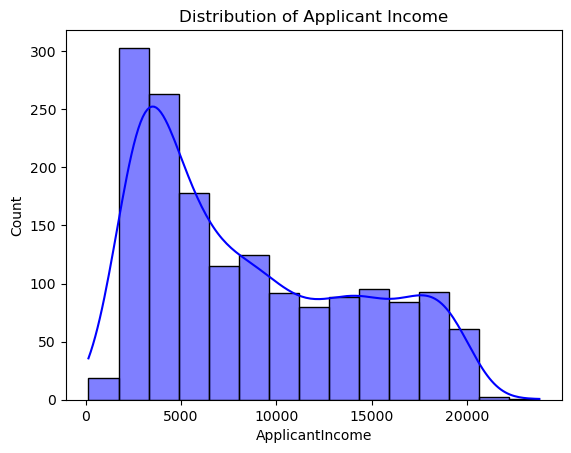

In [150]:
sns.histplot(loan.ApplicantIncome,kde=True,color='blue')
plt.title('Distribution of Applicant Income')

Text(0.5, 1.0, 'Distribution of CoapplicantIncome')

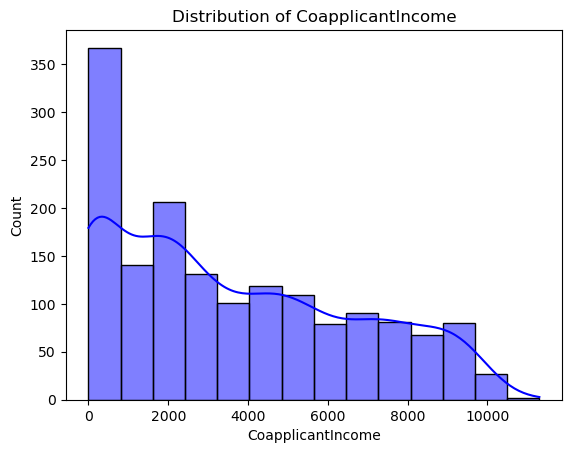

In [151]:
sns.histplot(loan.CoapplicantIncome,kde=True,color='blue')
plt.title('Distribution of CoapplicantIncome')

Text(0.5, 1.0, 'Distribution of LoanAmount')

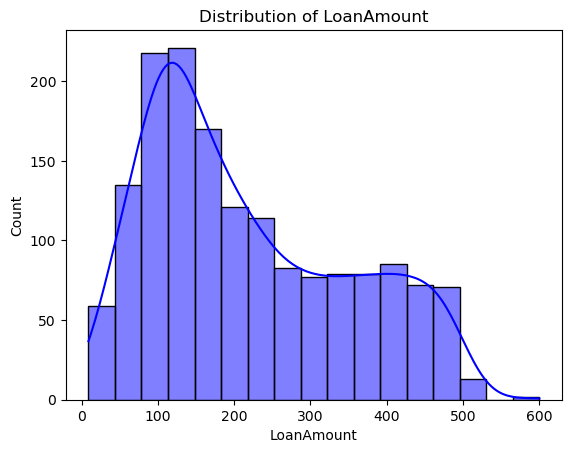

In [152]:
sns.histplot(loan.LoanAmount,kde=True,color='blue')
plt.title('Distribution of LoanAmount')

In [2]:
adult=pd.read_csv("adult.csv")

In [3]:
adult.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [158]:
adult.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [7]:
adult.duplicated().sum()

np.int64(52)

In [9]:
adult.drop_duplicates(inplace=True)

In [10]:
adult.age.unique()

array([25, 38, 28, 44, 18, 34, 29, 63, 24, 55, 65, 36, 26, 58, 48, 43, 20,
       37, 40, 72, 45, 22, 23, 54, 32, 46, 56, 17, 39, 52, 21, 42, 33, 30,
       47, 41, 19, 69, 50, 31, 59, 49, 51, 27, 57, 61, 64, 79, 73, 53, 77,
       80, 62, 35, 68, 66, 75, 60, 67, 71, 70, 90, 81, 74, 78, 82, 83, 85,
       76, 84, 89, 88, 87, 86])

In [11]:
adult.workclass.unique()

array(['Private', 'Local-gov', '?', 'Self-emp-not-inc', 'Federal-gov',
       'State-gov', 'Self-emp-inc', 'Without-pay', 'Never-worked'],
      dtype=object)

In [23]:
(adult=='?').sum()

age                   0
workclass          2795
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2805
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      856
income                0
dtype: int64

In [26]:
adult=adult.replace('?', np.nan)

In [30]:
adult.workclass.isna().sum()

np.int64(2795)

In [34]:
adult.workclass.fillna(adult.workclass.mode()[0],inplace=True)

In [37]:
adult.workclass.unique()

array(['Private', 'Local-gov', 'Self-emp-not-inc', 'Federal-gov',
       'State-gov', 'Self-emp-inc', 'Without-pay', 'Never-worked'],
      dtype=object)

In [38]:
adult.fnlwgt.unique()

array([226802,  89814, 336951, ..., 129912, 255835, 257302],
      shape=(28523,))

In [39]:
adult.fnlwgt.isna().sum()

np.int64(0)

In [40]:
adult.education.unique()

array(['11th', 'HS-grad', 'Assoc-acdm', 'Some-college', '10th',
       'Prof-school', '7th-8th', 'Bachelors', 'Masters', 'Doctorate',
       '5th-6th', 'Assoc-voc', '9th', '12th', '1st-4th', 'Preschool'],
      dtype=object)

In [41]:
adult['educational-num'].unique()

array([ 7,  9, 12, 10,  6, 15,  4, 13, 14, 16,  3, 11,  5,  8,  2,  1])

In [43]:
adult['educational-num'].isna().sum()

np.int64(0)

In [44]:
adult['marital-status'].unique()

array(['Never-married', 'Married-civ-spouse', 'Widowed', 'Divorced',
       'Separated', 'Married-spouse-absent', 'Married-AF-spouse'],
      dtype=object)

In [46]:
adult['marital-status'].isna().sum()

np.int64(0)

In [47]:
adult.occupation.isna().sum()

np.int64(2805)

In [49]:
adult.occupation.mode()[0]

'Prof-specialty'

In [51]:
adult.occupation.fillna(adult.occupation.mode()[0],inplace=True)

In [54]:
adult['native-country'].isna().sum()

np.int64(856)

In [56]:
adult['native-country'].mode()[0]

'United-States'

In [58]:
adult['native-country'].fillna(adult['native-country'].mode()[0],inplace=True)

In [59]:
adult.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48790 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48790 non-null  int64 
 1   workclass        48790 non-null  object
 2   fnlwgt           48790 non-null  int64 
 3   education        48790 non-null  object
 4   educational-num  48790 non-null  int64 
 5   marital-status   48790 non-null  object
 6   occupation       48790 non-null  object
 7   relationship     48790 non-null  object
 8   race             48790 non-null  object
 9   gender           48790 non-null  object
 10  capital-gain     48790 non-null  int64 
 11  capital-loss     48790 non-null  int64 
 12  hours-per-week   48790 non-null  int64 
 13  native-country   48790 non-null  object
 14  income           48790 non-null  object
dtypes: int64(6), object(9)
memory usage: 6.0+ MB


In [60]:
adult.relationship.unique() 

array(['Own-child', 'Husband', 'Not-in-family', 'Unmarried', 'Wife',
       'Other-relative'], dtype=object)

In [61]:
adult.race.unique()

array(['Black', 'White', 'Asian-Pac-Islander', 'Other',
       'Amer-Indian-Eskimo'], dtype=object)

In [62]:
adult.gender.unique() 

array(['Male', 'Female'], dtype=object)

In [63]:
adult['capital-gain'].unique() 

array([    0,  7688,  3103,  6418,  7298,  3908, 14084,  5178, 15024,
       99999,  2597,  2907,  4650,  6497,  1055,  5013, 27828,  4934,
        4064,  3674,  2174, 10605,  3418,   114,  2580,  3411,  4508,
        4386,  8614, 13550,  6849,  2463,  3137,  2885,  2964,  1471,
       10566,  2354,  1424,  1455,  3325,  4416, 25236,   594,  2105,
        4787,  2829,   401,  4865,  1264,  1506, 10520,  3464,  2653,
       20051,  4101,  1797,  2407,  3471,  1086,  1848, 14344,  1151,
        2993,  2290, 15020,  9386,  2202,  3818,  2176,  5455, 11678,
        7978,  7262,  6514, 41310,  3456,  7430,  2414,  2062, 34095,
        1831,  6723,  5060, 15831,  2977,  2346,  3273,  2329,  9562,
        2635,  4931,  1731,  6097,   914,  7896,  5556,  1409,  3781,
        3942,  2538,  3887, 25124,  7443,  5721,  1173,  4687,  6612,
        6767,  2961,   991,  2036,  2936,  2050,  1111,  2228, 22040,
        3432,  6360,  2009,  1639, 18481,  2387])

In [64]:
adult['capital-loss'].unique() 

array([   0, 1721, 1876, 2415, 1887,  625, 1977, 2057, 1429, 1590, 1485,
       2051, 2377, 1672, 1628, 1902, 1602, 1741, 2444, 1408, 2001, 2042,
       1740, 1825, 1848, 1719, 3004, 2179, 1573, 2205, 1258, 2339, 1726,
       2258, 1340, 1504, 2559, 1668, 1974, 1980, 1564, 2547, 2002, 1669,
       1617,  323, 3175, 2472, 2174, 1579, 2129, 1510, 1735, 2282, 1870,
       1411, 1911, 1651, 1092, 1762, 2457, 2231, 2238,  653, 1138, 2246,
       2603, 2392, 1944, 1380, 2465, 1421, 3770, 1594,  213, 2149, 2824,
       1844, 2467, 2163, 1816, 1648, 2206, 2352,  419, 1539,  880,  810,
        974, 4356, 2489, 1755, 3683, 2267, 2080,  155, 3900, 2201, 2754])

In [65]:
adult['hours-per-week'].unique() 

array([40, 50, 30, 32, 10, 39, 35, 48, 25, 20, 45, 47,  6, 43, 90, 54, 60,
       38, 36, 18, 24, 44, 56, 28, 16, 41, 22, 55, 14, 33, 37,  8, 12, 70,
       15, 75, 52, 84, 42, 80, 68, 99, 65,  5, 17, 72, 53, 29, 96, 21, 46,
        3,  1, 23, 49, 67, 76,  7,  2, 58, 26, 34,  4, 51, 78, 63, 31, 92,
       77, 27, 85, 13, 19, 98, 62, 66, 57, 11, 86, 59,  9, 64, 73, 61, 88,
       79, 89, 74, 69, 87, 97, 94, 82, 91, 81, 95])

In [66]:
adult['native-country'].unique() 

array(['United-States', 'Peru', 'Guatemala', 'Mexico',
       'Dominican-Republic', 'Ireland', 'Germany', 'Philippines',
       'Thailand', 'Haiti', 'El-Salvador', 'Puerto-Rico', 'Vietnam',
       'South', 'Columbia', 'Japan', 'India', 'Cambodia', 'Poland',
       'Laos', 'England', 'Cuba', 'Taiwan', 'Italy', 'Canada', 'Portugal',
       'China', 'Nicaragua', 'Honduras', 'Iran', 'Scotland', 'Jamaica',
       'Ecuador', 'Yugoslavia', 'Hungary', 'Hong', 'Greece',
       'Trinadad&Tobago', 'Outlying-US(Guam-USVI-etc)', 'France',
       'Holand-Netherlands'], dtype=object)

In [67]:
adult['income'].unique() 

array(['<=50K', '>50K'], dtype=object)

In [68]:
numeric_cols = adult.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    Q1 = adult[col].quantile(0.25)
    Q3 = adult[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = adult[(adult[col] < lower_bound) | (adult[col] > upper_bound)]
    print(f"Column '{col}' has {len(outliers)} outliers.")

Column 'age' has 215 outliers.
Column 'fnlwgt' has 1453 outliers.
Column 'educational-num' has 1787 outliers.
Column 'capital-gain' has 4035 outliers.
Column 'capital-loss' has 2282 outliers.
Column 'hours-per-week' has 13486 outliers.


In [69]:

print(f"Dataset shape BEFORE removing outliers: {adult.shape}")


columns_with_outliers = ['age', 'fnlwgt', 'educational-num', 'capital-gain','capital-loss','hours-per-week']


for col in columns_with_outliers:
    Q1 = adult[col].quantile(0.25)
    Q3 = adult[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
  
    adult =adult[(adult[col] >= lower_bound) & (adult[col] <= upper_bound)]

print(f"Dataset shape AFTER removing outliers: {adult.shape}")

Dataset shape BEFORE removing outliers: (48790, 15)
Dataset shape AFTER removing outliers: (28523, 15)


In [70]:
adult.describe()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,28523.000000,28523.000000,28523.000000,28523.0,28523.0,28523.000000
mean,38.048557,180460.318936,10.246187,0.0,0.0,41.470708
std,12.068195,87003.836080,2.148747,0.0,0.0,3.960450
min,17.000000,13769.000000,5.000000,0.0,0.0,33.000000
25%,28.000000,116933.500000,9.000000,0.0,0.0,40.000000
50%,37.000000,176683.000000,10.000000,0.0,0.0,40.000000
75%,47.000000,229641.000000,12.000000,0.0,0.0,40.000000
max,78.000000,417668.000000,16.000000,0.0,0.0,52.000000


In [71]:
# These five columns(age,fnlwgt,capital-gain,capital-loss and hours-per-week ) are the continuous numeric variables in adult dataset.So we draw
# hist plot for these columns.

Text(0.5, 1.0, 'Distribution of age')

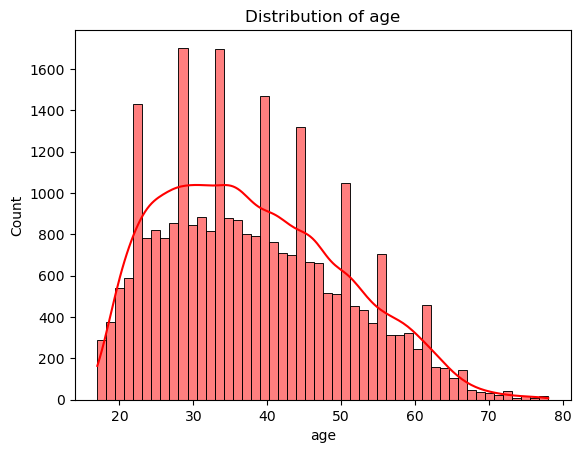

In [73]:
sns.histplot(adult.age,kde=True,color='red')
plt.title('Distribution of age')

Text(0.5, 1.0, 'Distribution of fnlwgt')

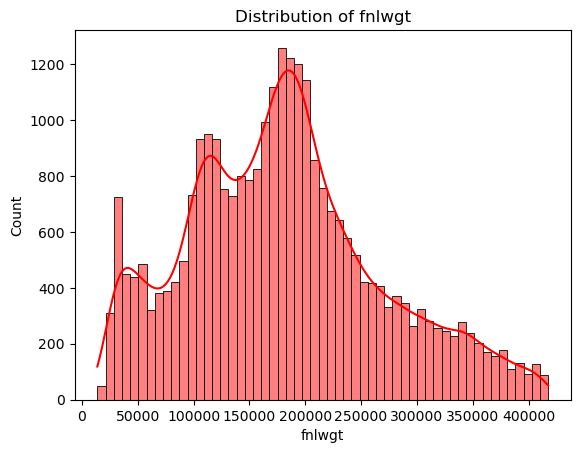

In [74]:
sns.histplot(adult.fnlwgt,kde=True,color='red')
plt.title('Distribution of fnlwgt')

Text(0.5, 1.0, 'Distribution of capital-gain')

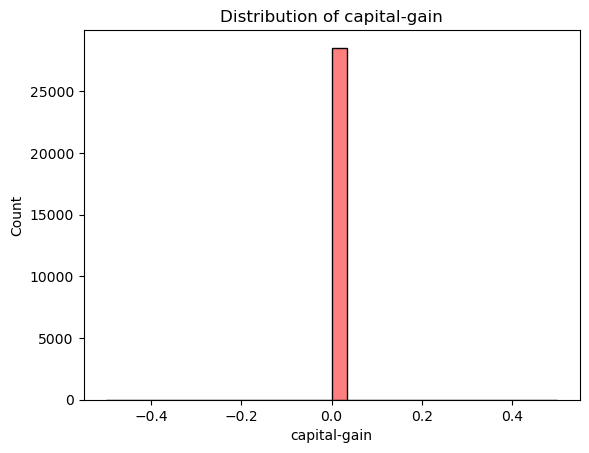

In [81]:
sns.histplot(adult['capital-gain'],kde=True,bins=30,color='red')
plt.title('Distribution of capital-gain')

Text(0.5, 1.0, 'Distribution of capital-loss')

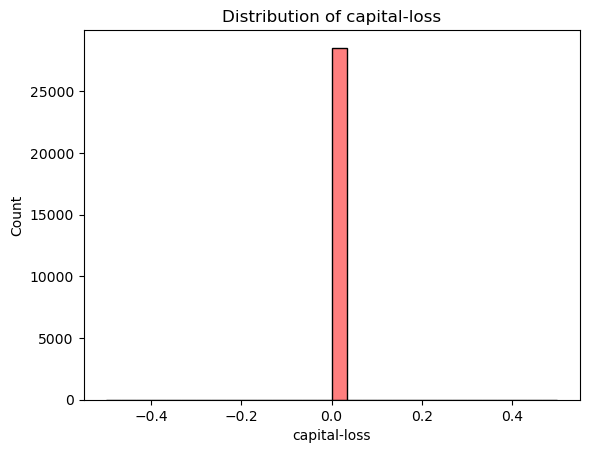

In [80]:
sns.histplot(adult['capital-loss'],bins=30,kde=True,color='red')
plt.title('Distribution of capital-loss')

Text(0.5, 1.0, 'Distribution of hours-per-week')

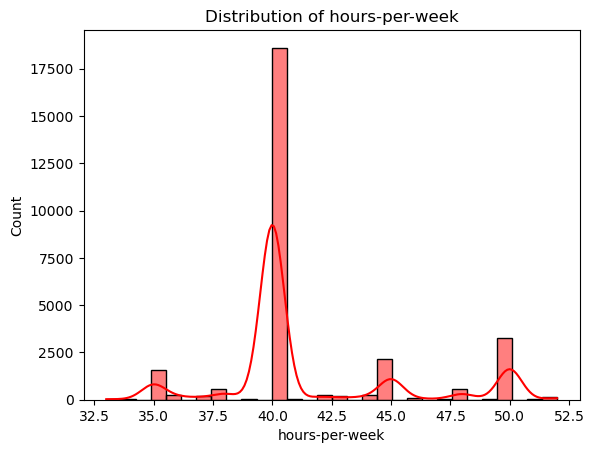

In [82]:
sns.histplot(adult['hours-per-week'],bins=30,kde=True,color='red')
plt.title('Distribution of hours-per-week')

In [83]:
hotel_booking=pd.read_csv("hotel_booking.csv")

In [84]:
hotel_booking.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [85]:
hotel_booking.shape

(119390, 36)

In [91]:
hotel_booking.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498


In [90]:
hotel_booking.drop(columns='company',axis=1,inplace=True)

In [92]:
hotel_booking.children.unique()

array([ 0.,  1.,  2., 10.,  3., nan])

In [93]:
hotel_booking.agent.unique()

array([ nan, 304., 240., 303.,  15., 241.,   8., 250., 115.,   5., 175.,
       134., 156., 243., 242.,   3., 105.,  40., 147., 306., 184.,  96.,
         2., 127.,  95., 146.,   9., 177.,   6., 143., 244., 149., 167.,
       300., 171., 305.,  67., 196., 152., 142., 261., 104.,  36.,  26.,
        29., 258., 110.,  71., 181.,  88., 251., 275.,  69., 248., 208.,
       256., 314., 126., 281., 273., 253., 185., 330., 334., 328., 326.,
       321., 324., 313.,  38., 155.,  68., 335., 308., 332.,  94., 348.,
       310., 339., 375.,  66., 327., 387., 298.,  91., 245., 385., 257.,
       393., 168., 405., 249., 315.,  75., 128., 307.,  11., 436.,   1.,
       201., 183., 223., 368., 336., 291., 464., 411., 481.,  10., 154.,
       468., 410., 390., 440., 495., 492., 493., 434.,  57., 531., 420.,
       483., 526., 472., 429.,  16., 446.,  34.,  78., 139., 252., 270.,
        47., 114., 301., 193., 182., 135., 350., 195., 352., 355., 159.,
       363., 384., 360., 331., 367.,  64., 406., 16

In [95]:
hotel_booking.country.unique()

array(['PRT', 'GBR', 'USA', 'ESP', 'IRL', 'FRA', nan, 'ROU', 'NOR', 'OMN',
       'ARG', 'POL', 'DEU', 'BEL', 'CHE', 'CN', 'GRC', 'ITA', 'NLD',
       'DNK', 'RUS', 'SWE', 'AUS', 'EST', 'CZE', 'BRA', 'FIN', 'MOZ',
       'BWA', 'LUX', 'SVN', 'ALB', 'IND', 'CHN', 'MEX', 'MAR', 'UKR',
       'SMR', 'LVA', 'PRI', 'SRB', 'CHL', 'AUT', 'BLR', 'LTU', 'TUR',
       'ZAF', 'AGO', 'ISR', 'CYM', 'ZMB', 'CPV', 'ZWE', 'DZA', 'KOR',
       'CRI', 'HUN', 'ARE', 'TUN', 'JAM', 'HRV', 'HKG', 'IRN', 'GEO',
       'AND', 'GIB', 'URY', 'JEY', 'CAF', 'CYP', 'COL', 'GGY', 'KWT',
       'NGA', 'MDV', 'VEN', 'SVK', 'FJI', 'KAZ', 'PAK', 'IDN', 'LBN',
       'PHL', 'SEN', 'SYC', 'AZE', 'BHR', 'NZL', 'THA', 'DOM', 'MKD',
       'MYS', 'ARM', 'JPN', 'LKA', 'CUB', 'CMR', 'BIH', 'MUS', 'COM',
       'SUR', 'UGA', 'BGR', 'CIV', 'JOR', 'SYR', 'SGP', 'BDI', 'SAU',
       'VNM', 'PLW', 'QAT', 'EGY', 'PER', 'MLT', 'MWI', 'ECU', 'MDG',
       'ISL', 'UZB', 'NPL', 'BHS', 'MAC', 'TGO', 'TWN', 'DJI', 'STP',
       'KNA', 'E

In [97]:
hotel_booking.country.mode()[0]

'PRT'

In [98]:
hotel_booking.children = hotel_booking.children.fillna(0).astype(int)
hotel_booking.agent = hotel_booking.agent.fillna(0).astype(int)
hotel_booking.country = hotel_booking.country.fillna(hotel_booking.country.mode()[0])

In [105]:
combined_date_string = (
    hotel_booking['arrival_date_year'].astype(str) + '-' + 
    hotel_booking['arrival_date_month'] + '-' + 
    hotel_booking['arrival_date_day_of_month'].astype(str))
hotel_booking['arrival_date'] = pd.to_datetime(combined_date_string, format='%Y-%B-%d')

In [107]:
hotel_booking = hotel_booking.drop(columns=['arrival_date_year', 'arrival_date_month', 'arrival_date_day_of_month'])

In [103]:
hotel_booking.drop_duplicates(inplace=True)

In [108]:
hotel_booking.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 33 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   hotel                           119390 non-null  object        
 1   is_canceled                     119390 non-null  int64         
 2   lead_time                       119390 non-null  int64         
 3   arrival_date_week_number        119390 non-null  int64         
 4   stays_in_weekend_nights         119390 non-null  int64         
 5   stays_in_week_nights            119390 non-null  int64         
 6   adults                          119390 non-null  int64         
 7   children                        119390 non-null  int64         
 8   babies                          119390 non-null  int64         
 9   meal                            119390 non-null  object        
 10  country                         119390 non-null  object 

In [109]:
numeric_cols = hotel_booking.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    Q1 = hotel_booking[col].quantile(0.25)
    Q3 = hotel_booking[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = hotel_booking[(hotel_booking[col] < lower_bound) | (hotel_booking[col] > upper_bound)]
    print(f"Column '{col}' has {len(outliers)} outliers.")

Column 'is_canceled' has 0 outliers.
Column 'lead_time' has 3005 outliers.
Column 'arrival_date_week_number' has 0 outliers.
Column 'stays_in_weekend_nights' has 265 outliers.
Column 'stays_in_week_nights' has 3354 outliers.
Column 'adults' has 29710 outliers.
Column 'children' has 8590 outliers.
Column 'babies' has 917 outliers.
Column 'is_repeated_guest' has 3810 outliers.
Column 'previous_cancellations' has 6484 outliers.
Column 'previous_bookings_not_canceled' has 3620 outliers.
Column 'booking_changes' has 18076 outliers.
Column 'agent' has 1254 outliers.
Column 'days_in_waiting_list' has 3698 outliers.
Column 'adr' has 3793 outliers.
Column 'required_car_parking_spaces' has 7416 outliers.
Column 'total_of_special_requests' has 2877 outliers.


In [110]:
print(f"Dataset shape BEFORE removing outliers: {hotel_booking.shape}")


columns_with_outliers = ['lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults','children','babies','is_repeated_guest',
                         'previous_cancellations','previous_bookings_not_canceled','booking_changes','agent','days_in_waiting_list',
                         'adr','required_car_parking_spaces','total_of_special_requests']


for col in columns_with_outliers:
    Q1 = hotel_booking[col].quantile(0.25)
    Q3 = hotel_booking[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
  
    hotel_booking =hotel_booking[(hotel_booking[col] >= lower_bound) & (hotel_booking[col] <= upper_bound)]

print(f"Dataset shape AFTER removing outliers: {hotel_booking.shape}")

Dataset shape BEFORE removing outliers: (119390, 33)
Dataset shape AFTER removing outliers: (53554, 33)


Text(0, 0.5, 'Count')

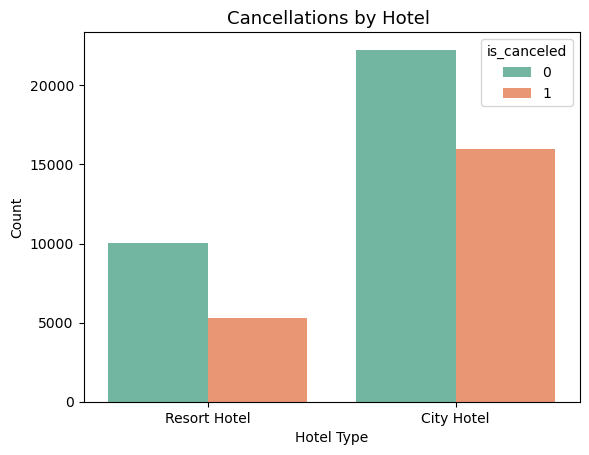

In [112]:
sns.countplot(x='hotel', hue='is_canceled', data=hotel_booking,palette='Set2')
plt.title('Cancellations by Hotel ', fontsize=13)
plt.xlabel('Hotel Type')
plt.ylabel('Count')


Text(0, 0.5, 'Lead Time (Days)')

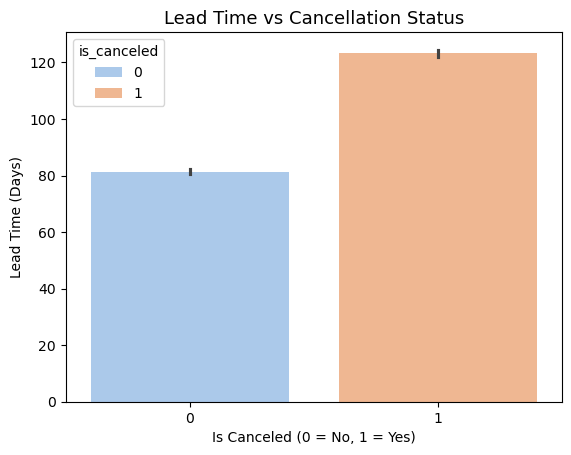

In [119]:
sns.barplot(x='is_canceled', y='lead_time', data=hotel_booking,hue='is_canceled', palette='pastel')
plt.title('Lead Time vs Cancellation Status', fontsize=13)
plt.xlabel('Is Canceled (0 = No, 1 = Yes)')
plt.ylabel('Lead Time (Days)')